The commutator optimization thing doesn't seem to work very well.

In [114]:
import sys

sys.path.insert(0, "..")
from scipy.optimize import OptimizeResult
from scipy.stats import special_ortho_group
import copy

from optimize_for_commutator import *

In [43]:
mol = get_mol("lih", 1.0)

n_e = mol.n_electrons
n_qubits = 2 * mol.n_orbitals
dim = 1 << n_qubits
n_orbitals = mol.n_orbitals

H_ferm = get_fermion_operator(mol.get_molecular_hamiltonian())
H_qubit = jordan_wigner(H_ferm)
H_full = get_sparse_operator(H_qubit, n_qubits).tocsc()

# Fixed-N basis
basis_bitstrings = [b for b in range(dim) if popcount(b) == n_e]
basis_idx = np.array(basis_bitstrings, dtype=int)

H_sub = H_full[basis_idx, :][:, basis_idx].tocsc()
evals, evecs = spla.eigsh(H_sub, k=1, which="SA")
E_fci = float(np.real(evals[0]))
v_sub = evecs[:, 0]

# Full-space FCI state
psi_full = np.zeros(dim, dtype=np.complex128)
psi_full[basis_idx] = v_sub
psi_full /= np.linalg.norm(psi_full)

In [20]:
h = mol.get_molecular_hamiltonian()
type(h)

openfermion.ops.representations.interaction_operator.InteractionOperator

In [48]:
U = special_ortho_group.rvs(mol.n_orbitals)

In [57]:
symmetry = (of.FermionOperator(((0, 1), (0, 0)), 1)
              + of.FermionOperator(((1, 1), (1, 0)), 1)
              + of.FermionOperator(((0, 1), (0, 0)), -2) * of.FermionOperator(((1, 1), (1, 0)), 1))

In [115]:
symmetries = [(of.FermionOperator(((2 * i, 1), (2 * i, 0)), 1)
              + of.FermionOperator(((2 * i + 1, 1), (2 * i + 1, 0)), 1)
              + of.FermionOperator(((2 * i, 1), (2 * i, 0)), -2) 
               * of.FermionOperator(((2 * i + 1, 1), (2 * i + 1, 0)), 1))
             for i in range(mol.n_orbitals)]

symmetry_inter_ops = [of.get_interaction_operator(s, n_qubits=n_qubits) for s in symmetries]


In [73]:
symmetry_inter_op = of.get_interaction_operator(symmetry, n_qubits=n_qubits)
n_body_tensors = {(1, 0): symmetry_inter_op.one_body_tensor,
                  (1, 1, 0, 0): symmetry_inter_op.two_body_tensor}


symmetry_pt = of.PolynomialTensor(n_body_tensors)

In [117]:
%%time

total = 0

U = special_ortho_group.rvs(mol.n_orbitals)

rotated_symmetries = [copy.deepcopy(op) for op in symmetry_inter_ops]
for op in rotated_symmetries:
    op.rotate_basis(U)
for op in rotated_symmetries:
    op_mat = of.get_sparse_operator(op)
    comm = H_full @ op_mat - op_mat @ H_full
    total += np.linalg.norm(comm @ psi_full)

# s = of.get_fermion_operator(symmetry_pt)

# comm = of.commutator(H_ferm, s)
# comm_mat = of.get_sparse_operator(comm)

# w = of.commutator(h_2, symmetry_pt)

# s = of.get_sparse_operator(symmetry_pt)

# comm = H_full @ s - s @ H_full

# print(np.linalg.norm(comm @ psi_full))

CPU times: user 3.95 s, sys: 765 ms, total: 4.71 s
Wall time: 3.87 s


In [141]:
def commutator_cost(x):
    a = np.sin(x[m]) * np.cos(x[m + 1])
    b = np.sin(x[m]) * np.sin(x[m + 1])
    c = np.cos(x[m])
    U = build_U_from_thetas(n_orbitals, x[:m], pairs)
    symmetries = [(of.FermionOperator(((2 * i, 1), (2 * i, 0)), a)
              + of.FermionOperator(((2 * i + 1, 1), (2 * i + 1, 0)), b)
              + of.FermionOperator(((2 * i, 1), (2 * i, 0)), c) 
               * of.FermionOperator(((2 * i + 1, 1), (2 * i + 1, 0)), 1))
             for i in range(mol.n_orbitals)]

    symmetry_inter_ops = [of.get_interaction_operator(s, n_qubits=n_qubits) for s in symmetries]
    total = 0
    
    # rotated_symmetries = [copy.deepcopy(op) for op in symmetry_inter_ops]
    for op in symmetry_inter_ops:
        op.rotate_basis(U)
        op_mat = of.get_sparse_operator(op, n_qubits=n_qubits)
        print(op_mat.shape)
        comm = H_full @ op_mat - op_mat @ H_full
        total += np.linalg.norm(comm @ psi_full)
    return total

In [140]:
op_mat.shape

(4096, 4096)

In [135]:
x = rng.normal(size=m + 2)

In [136]:
x.shape

(17,)

In [131]:
np.zeros_like(x).shape

(17,)

In [142]:
%%time
commutator_cost(np.zeros_like(x))
# commutator_cost(x)

(4, 4)


ValueError: dimension mismatch

In [121]:
f(x)

1.6776353614082382

In [3]:
evals

array([-7.78446028])

In [4]:
psi_full.T.conj() @ H_full @ psi_full

(-7.784460280031212+4.440892098500626e-16j)

In [5]:
f = commutator_cost_function_fixed_abc(H_full, psi_full)
g = sum_of_variances_cost_function_fixed_abc(psi_full)

In [6]:
pairs = list(combinations(range(mol.n_orbitals), 2))
m = len(pairs)

In [7]:
%%time

rng = np.random.default_rng()
x = rng.normal(size = m + 2)
print(f(x))

3.7810423689309784
CPU times: user 19.7 s, sys: 251 ms, total: 19.9 s
Wall time: 20.5 s


In [8]:
g(x)

1.2205424259376414

In [9]:
x_0 = rng.normal(scale = 1e-3, size = m + 2)

In [10]:
%%time

g(x)

CPU times: user 1.26 ms, sys: 46 μs, total: 1.3 ms
Wall time: 1.22 ms


1.2205424259376414

In [11]:
%%time

x = rng.normal(size = m + 2)
print(f(x))

2.8350396313742814
CPU times: user 16.1 s, sys: 159 ms, total: 16.2 s
Wall time: 16.2 s


In [28]:
g(x_0)

0.030305717131741742

In [36]:
funvals = []

def callback(intermediate_result: OptimizeResult):
    print(intermediate_result.fun)
    funvals.append(intermediate_result.fun)

In [37]:
res_var = minimize(g, x_0, method="L-BFGS-B",
                   options={"maxiter": 100}, callback=callback)

print(res_var.message)

0.029290080664297585
0.026315521849472612
0.024531722150095605
0.015633531504401173
0.007106876100762799
0.0038583945158761975
0.00223417833234493
0.0022100434665736535
0.0021425400579556126
0.0016170760778130302
0.0011123425280955297
0.0006291141016933802
4.1562117835901335e-05
2.8156463809714057e-05
2.7562563797304305e-05
2.729547655645852e-05
2.698010724463768e-05
2.5771575095505395e-05
2.5094648138591632e-05
2.503568495034899e-05
2.487566152157784e-05
2.4867659479594087e-05
2.4867233517705875e-05
CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


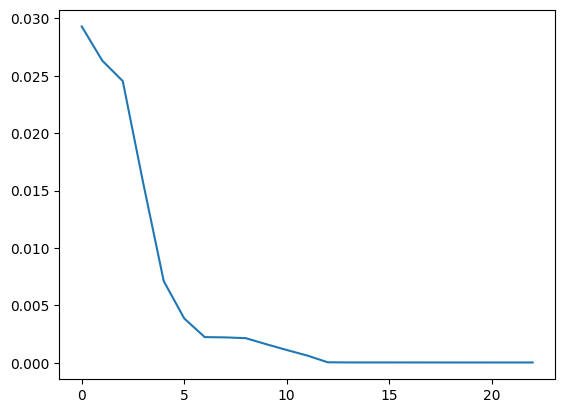

In [38]:
plt.plot(funvals)

In [12]:
res_var

  message: STOP: TOTAL NO. of ITERATIONS REACHED LIMIT
  success: False
   status: 1
      fun: 0.029272363611868274
        x: [ 2.760e-03 -2.818e-03 ... -3.609e-02 -2.243e-04]
      nit: 1
      jac: [-2.625e-03 -9.295e-03 ...  5.899e-02 -2.071e-03]
     nfev: 54
     njev: 3
 hess_inv: <17x17 LbfgsInvHessProduct with dtype=float64>

In [15]:
a = np.sin(x[m]) * np.cos(x[m + 1])
b = np.sin(x[m]) * np.sin(x[m + 1])
c = np.cos(x[m])
U = build_U_from_thetas(n_orbitals, x[:m], pairs)
total_commutator_norm = 0
for i in range(1):
    Si_ferm = build_single_local_operator(U, n_orbitals, i,
            [(a, b, c)] * n_orbitals)
    # Si_ferm = normal_ordered(
    #     rotated_seniority_orbital_fermion(
    #         U, i, n_orbitals, a, b, c
    #     )
    # )
    Si_mat = fermion_to_sparse_qubit(Si_ferm, n_qubits)
    total_commutator_norm += expected_squared_commutator(
        H_full, Si_mat, psi_full)

In [16]:
Si_ferm

-4.811543515482759e-05 [0^ 0] +
-1.0823988783000811e-05 [0^ 2] +
2.9661122899527265e-05 [0^ 4] +
0.00024542496907131495 [0^ 6] +
-0.00015595855854748622 [0^ 8] +
-0.0001470449030463651 [0^ 10] +
-0.0004371344186423013 [1^ 0^ 1 0] +
9.833721816757006e-05 [1^ 0^ 2 1] +
-9.833721816757006e-05 [1^ 0^ 3 0] +
-2.2121818974975785e-05 [1^ 0^ 3 2] +
-0.0002694748093463266 [1^ 0^ 4 1] +
-6.062071982265484e-05 [1^ 0^ 4 3] +
0.0002694748093463266 [1^ 0^ 5 0] +
6.062071982265484e-05 [1^ 0^ 5 2] +
-0.0001661197786662044 [1^ 0^ 5 4] +
-0.0022297148686294256 [1^ 0^ 6 1] +
-0.0005015938991235235 [1^ 0^ 6 3] +
0.0013745245478193507 [1^ 0^ 6 5] +
0.0022297148686294256 [1^ 0^ 7 0] +
0.0005015938991235235 [1^ 0^ 7 2] +
-0.0013745245478193507 [1^ 0^ 7 4] +
-0.01137322567925113 [1^ 0^ 7 6] +
0.001416901948482253 [1^ 0^ 8 1] +
0.0003187445098986106 [1^ 0^ 8 3] +
-0.0008734598927615652 [1^ 0^ 8 5] +
-0.007227267419786652 [1^ 0^ 8 7] +
-0.001416901948482253 [1^ 0^ 9 0] +
-0.0003187445098986106 [1^ 0^ 9 2] +
0.0